In [62]:
import datetime 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path

import utilities.simple_read_repos_from_file as repo_reader
from utilities.repo_names_write_out import RepoNamesListCreator
from githubanalysis.analysis.analyse_data import DataAnalyser

dataanalyser = DataAnalyser(in_notebook=True, logger=None, dataset_name="set_comparison")

current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

2026-03-24


In [63]:
location_tag = "analysis_set_comparison/dataset_comparison"
set1_sample_location_tag = "analysis_run_sample_45pc_2025-05-12/"
set2_sample_location_tag = "analysis_run_set2w100_2026-03-20/set2w100pc_"

In [64]:
# all eligible repo names: 
eligible_supersample = "../../data/study-sample-repo-names_2025-05-01_x2981.txt"
# Set1 (ECEASST dataset) repo names
set1_sample = "../../data/sample_45pc_subsample_repo_names_list_2025-05-12_x1284.txt"
set2_sample = " set2_sample_55pc_subsample_repo_names_list_2026-02-26_x1697.txt"

In [65]:
# plotting details: 
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 

set_colour_dict = {"set1": "green", "set2": "purple"}

# savefig kwargs
saveout_args = dict(dpi=400, format="pdf", bbox_inches="tight", )

orig_data_file = "../../data/merged-data-per-dev_x2868-repos_2025-05-10.csv"

set1_analysis_dataset_file = "../../data/analysis_run_sample_45pc_2025-05-12/clustered_sample_data_with_labels__2025-05-12.csv"
set2_analysis_dataset_file = "../../data/analysis_run_set2w100_2026-03-20/clustered_sample_data_with_labels__2026-03-20.csv"
# via:  "../../data/merged-data-per-dev_x2868-repos_2025-05-10.csv" and merged-interactions-data-per-dev_x2946-repos_2025-05-12.csv
repo_stats_file = "../../data/summarised_SAMPLE_repos_stats_2025-05-09.csv"
study_repos_file = "../../data/study-sample-repo-names_2025-05-01_x2981.txt"

# read in the analysed datasets with cluster labels
set1_analysis_dataset = pd.read_csv(set1_analysis_dataset_file, header=0, low_memory=False)
set2_analysis_dataset = pd.read_csv(set2_analysis_dataset_file, header=0, low_memory=False)

orig_dataset = pd.read_csv(orig_data_file, header=0, low_memory=False)


In [93]:
dataset1 = {
    "dataset_name": "Set1", 
    "dataset_df": set1_analysis_dataset, 
    "dataset_colour": "xkcd:pea green", 
    "dataset_Nrepos": set1_analysis_dataset.repo_name.nunique(),
    "dataset_Nrepoindivids": len(set1_analysis_dataset),
    "dataset_clustering_date":"2025-05-12",
    "dataset_sample_location_tag":set1_sample_location_tag,
}
dataset2 = {
    "dataset_name": "Set2", 
    "dataset_df": set2_analysis_dataset, 
    "dataset_colour": "xkcd:royal purple", 
    "dataset_Nrepos": set2_analysis_dataset.repo_name.nunique(),
    "dataset_Nrepoindivids": len(set2_analysis_dataset),
    "dataset_clustering_date":"2026-03-20",
    "dataset_sample_location_tag": set2_sample_location_tag,
} 

datasets_to_compare = [dataset1, dataset2]

In [101]:
dataset1.get("dataset_Nrepoindivids")

115174

In [102]:
dataset2.get("dataset_Nrepoindivids")

127372

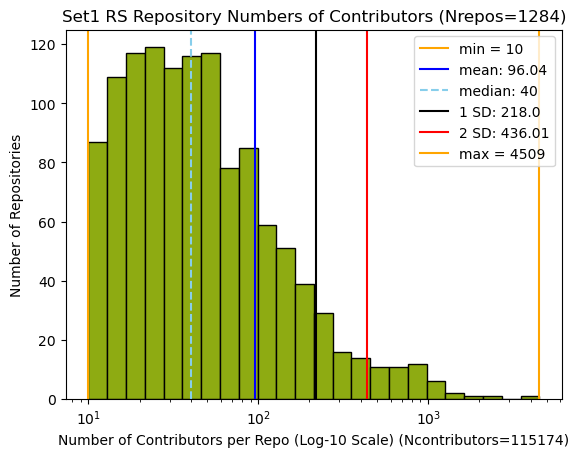

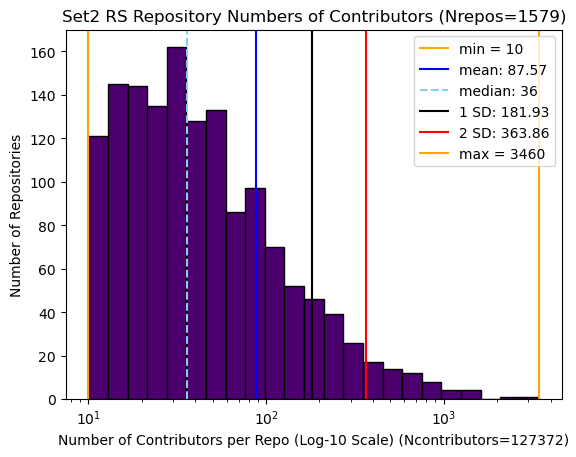

In [104]:
for dataset in datasets_to_compare:
    
    repo_size_plotting(
        dataset_name=dataset.get("dataset_name"), 
        analysis_dataset=dataset.get("dataset_df"), 
        data_colour=dataset.get("dataset_colour"),  
        sample_location_tag=dataset.get("dataset_sample_location_tag"), 
        saveout_args = saveout_args
    )


In [103]:
def repo_size_plotting(dataset_name:str, analysis_dataset:pd.DataFrame, data_colour, sample_location_tag: str | Path, saveout_args:dict,):
    """
    Function which will plot per-unique-RS-repo contributor numbers 
    on a log^10 scale and show descriptive stats in the legend.
    Y axis demonstrates how many repositories contain the 'binned' 
    number of contributors.
    
    Saves images out to images/ folder.
    
    To adjust file save out details, edit the saveout_args dictionary values argument.
    Default saveout_args = dict(dpi=400, format="pdf", bbox_inches="tight", )
    """

    repo_size = analysis_dataset.groupby("repo_name")[["gh_username"]].count().reset_index(names=["repo_name", "contributors"])
    repo_size.rename(columns={"gh_username": "contributors"}, inplace=True)

    repo_size = repo_size.query("contributors >= 10")

    N_repos = analysis_dataset["repo_name"].nunique()

    ax = sns.histplot(x=repo_size.contributors, alpha=1, log_scale=10, color=data_colour,)
    ax.set_title(f"{dataset_name} RS Repository Numbers of Contributors (Nrepos={N_repos})")
    ax.set_ylabel("Number of Repositories")

    ax.set_xlabel(f"Number of Contributors per Repo (Log-10 Scale) (Ncontributors={len(analysis_dataset)})")
    pop2SD = (repo_size.contributors.std()*2)
    ax.axvline(x=10, color="orange").set_label("min = 10")
    ax.axvline(x=repo_size.contributors.mean(), color="blue").set_label(f"mean: {round(repo_size.contributors.mean(), 2)}") ## THIS IS mean
    ax.axvline(x=repo_size.contributors.median(), color="skyblue", linestyle="--").set_label(f"median: {round(repo_size.contributors.median())}") ## THIS IS median
    ax.axvline(x=repo_size.contributors.std(), color="black").set_label(f"1 SD: {round(repo_size.contributors.std(), 2)}") ## THIS IS 1 Std Deviation 
    ax.axvline(x=pop2SD, color="red").set_label(f"2 SD: { round((repo_size.contributors.std()*2), 2)}") ## THIS IS 2 Std Deviations 
    ax.axvline(x=repo_size.contributors.max(), color="orange").set_label(f"max = {repo_size.contributors.max()}")

    ax.legend()  # adds the line legend in 
    plt.savefig(f"../../images/{sample_location_tag}_sample_teamsizes_logplot.pdf", **saveout_args)
    plt.show()